# Análisis Exploratorio de Datos (EDA)
## Airbnb Ciudad Autónoma de Buenos Aires, Argentina
### Inteligencia de Negocios — Taller Evaluativo 2

**Objetivo:** Comprender la estructura, calidad y distribución de los datos antes de realizar las transformaciones del proceso ETL.

---

In [18]:
import sys
import os
sys.path.append(os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from extraccion import Extraccion

# Configuracion general de graficas
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


---
## 1. Extracción de datos desde MongoDB

In [19]:
# Conectar a MongoDB y extraer las tres colecciones
ext = Extraccion()
df_listings, df_reviews, df_calendar = ext.extraer_todo()
ext.cerrar_conexion()

print(f'Listings:  {len(df_listings):,} registros')
print(f'Reviews:   {len(df_reviews):,} registros')
print(f'Calendar:  {len(df_calendar):,} registros')

2026-04-04 15:09:21 - INFO - Logger iniciado para el modulo: extraccion
2026-04-04 15:09:21 - INFO - Archivo de log: logs\log_extraccion_20260404_1509.txt
2026-04-04 15:09:21 - INFO - Intentando conectar a MongoDB: mongodb://localhost:27017/
2026-04-04 15:09:21 - INFO - Conexion exitosa a la base de datos: 'airbnb_itm'
2026-04-04 15:09:21 - INFO - Iniciando extraccion completa de todas las colecciones.
2026-04-04 15:09:21 - INFO - Extrayendo coleccion: 'Listings'
2026-04-04 15:09:22 - INFO - Coleccion 'Listings' extraida correctamente. Registros: 27,348 | Columnas: 71
2026-04-04 15:09:22 - INFO - Extrayendo coleccion: 'Reviews'
2026-04-04 15:09:28 - INFO - Coleccion 'Reviews' extraida correctamente. Registros: 1,042,702 | Columnas: 6
2026-04-04 15:09:28 - INFO - Extrayendo coleccion: 'Calendar'
2026-04-04 15:10:13 - INFO - Coleccion 'Calendar' extraida correctamente. Registros: 9,982,072 | Columnas: 5
2026-04-04 15:10:13 - INFO - Extraccion finalizada. Resumen: Listings=27,348 | Review

Listings:  27,348 registros
Reviews:   1,042,702 registros
Calendar:  9,982,072 registros


---
## 2. Entendimiento general — Listings

El dataset de **listings** contiene información detallada de cada alojamiento publicado en Airbnb para Buenos Aires.


In [20]:
# Primeras filas
df_listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_is_superhost,host_picture_url,host_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,...,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,host_location,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,host_about,license
0,42610838,https://www.airbnb.com/rooms/42610838,20260125052844,2026-01-25,city scrape,"Puerto Madero a 3 cuadras, centro, bello , tea...","Unbeatable location half a block away, 50 mete...",https://a0.muscache.com/pictures/miso/Hosting-...,224049389,https://www.airbnb.com/users/show/224049389,1469188629918707060,https://www.airbnb.com/users/profile/146918862...,Gabriela,7,2,5,11,True,https://a0.muscache.com/im/pictures/user/ba7f6...,3,None,True,True,San Nicolas,-34.60,...,244,2026-01-25,0,0,0,220,0,0,2,2,0,0,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1305876403852901802,https://www.airbnb.com/rooms/1305876403852901802,20260125052844,2026-01-25,city scrape,Apart estudio en Microcentro,"Located in the heart of Buenos Aires, this stu...",https://a0.muscache.com/pictures/miso/Hosting-...,25649070,https://www.airbnb.com/users/show/25649070,1465347917068117288,https://www.airbnb.com/users/profile/146534791...,Federico,11,0,3,7,False,https://a0.muscache.com/im/users/25649070/prof...,1,None,True,True,San Nicolas,-34.60,...,307,2026-01-25,1,0,0,283,1,0,1,1,0,0,"Autonomous City of Buenos Aires, Argentina",2025-01-18,2025-01-18,3.00,4.00,2.00,3.00,3.00,5.00,4.00,0.08,NaN,NaN
2,1542233033640525302,https://www.airbnb.com/rooms/1542233033640525302,20260125052844,2026-01-25,city scrape,"Departamento en Buenos Aires, abasto shopping",From this central accommodation your group wil...,https://a0.muscache.com/pictures/hosting/Hosti...,153014015,https://www.airbnb.com/users/show/153014015,1468500000533080859,https://www.airbnb.com/users/profile/146850000...,Marco,8,3,7,10,False,https://a0.muscache.com/im/pictures/user/4e988...,1,None,True,True,Balvanera,-34.60,...,326,2026-01-25,0,0,0,302,0,0,1,1,0,0,"Olivos, Argentina",NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Responsable amable atento y amigable,NaN
3,1004530078359434134,https://www.airbnb.com/rooms/1004530078359434134,20260125052844,2026-01-25,city scrape,Departamento en Recoleta,Relax with the whole family at this peaceful p...,https://a0.muscache.com/pictures/0beb83d5-381d...,1409800,https://www.airbnb.com/users/show/1409800,1462517876404348407,https://www.airbnb.com/users/profile/146251787...,Marian,14,2,14,1,False,https://a0.muscache.com/im/pictures/user/User-...,48,None,True,True,Balvanera,-34.60,...,365,2026-01-25,22,3,0,341,3,18,39,34,4,0,"Buenos Aires, Argentina",2023-10-29,2025-12-07,4.73,4.64,4.64,4.82,4.73,4.59,4.45,0.80,I'm a young entrepreneur who enjoys the pleasu...,NaN
4,800145927121871422,https://www.airbnb.com/rooms/800145927121871422,20260125052844,2026-01-25,city scrape,Coqueto para 4 personas,3 rooms: master bedroom with king size bed and...,https://a0.muscache.com/pictures/d2a502bc-2ac0...,467965425,https://www.airbnb.com/users/show/467965425,1470109782901816721,https://www.airbnb.com/users/profile/147010978...,Maria Del Carmen,3,6,2,8,False,https://a0.muscache.com/im/pictures/user/dbfd3...,2,None,True,True,Almagro,-34.60,...,365,2026-01-25,0,0,0,341,0,0,2,2,0,0,"Buenos Aires, Argentina",NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,N

In [21]:
# Dimensiones
print(f'Shape: {df_listings.shape}')
print(f'Registros: {df_listings.shape[0]:,}')
print(f'Columnas: {df_listings.shape[1]}')

Shape: (27348, 71)
Registros: 27,348
Columnas: 71


In [22]:
# Tipos de datos
df_listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 27348 entries, 0 to 27347
Data columns (total 71 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            27348 non-null  int64         
 1   listing_url                                   27348 non-null  str           
 2   scrape_id                                     27348 non-null  int64         
 3   last_scraped                                  27348 non-null  datetime64[us]
 4   source                                        27348 non-null  str           
 5   name                                          27348 non-null  str           
 6   description                                   26752 non-null  str           
 7   picture_url                                   27347 non-null  str           
 8   host_id                                       27348 non-null  int64         


In [ ]:
# Estadísticas descriptivas de variables numéricas disponibles en Listings
cols_numericas = ['accommodates', 'bathrooms', 'bedrooms', 'beds',
                  'minimum_nights', 'maximum_nights', 'availability_365',
                  'number_of_reviews', 'host_listings_count',
                  'estimated_occupancy_l365d']
cols_presentes = [c for c in cols_numericas if c in df_listings.columns]
df_listings[cols_presentes].describe()

,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_365,number_of_reviews,host_listings_count,estimated_occupancy_l365d
count,27348.00,27340.00,27288.00,27340.00,27242.00,27242.00,27348.00,27348.00,27348.00,27348.00
mean,2.95,1.23,1.16,1.90,4.75,586.12,240.00,38.13,17.92,72.48
std,1.57,0.67,0.91,1.52,16.43,434.07,113.61,56.08,38.40,80.94
min,1.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00
25%,2.00,1.00,1.00,1.00,1.00,365.00,151.00,4.00,1.00,6.00
50%,2.00,1.00,1.00,1.00,2.00,365.00,269.00,17.00,3.00,42.00
75%,4.00,1.00,1.00,2.00,3.00,1125.00,344.00,51.00,16.00,120.00
max,16.00,22.00,22.00,40.00,730.00,1825.00,365.00,1044.00,945.00,255.00


In [34]:
# Estadísticas descriptivas de variables categóricas/booleanas relevantes en Listings
cols_cat = ['neighbourhood_cleansed', 'room_type', 'property_type', 'host_is_superhost', 'has_availability']
cols_presentes_cat = [c for c in cols_cat if c in df_listings.columns]

if cols_presentes_cat:
    print("--- Variables Categóricas y Booleanas ---")
    print(df_listings[cols_presentes_cat].astype('object').describe())

--- Variables Categóricas y Booleanas ---
       neighbourhood_cleansed        room_type       property_type  \
count                   27348            27348               27348   
unique                     48                4                  58   
top                   Palermo  Entire home/apt  Entire rental unit   
freq                     8963            24890               19895   

       host_is_superhost has_availability  
count              27348            27144  
unique                 2                1  
top                False             True  
freq               15862            27144  


---
## 3. Entendimiento general — Reviews

In [24]:
df_reviews.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,11508,1615861,2012-07-02,877808,Charlie,Amazing place!\r<br/>\r<br/>Location: short wa...
1,11508,3157005,2012-12-26,656077,Shaily,Really enjoyed Candela's recommendations and q...
2,11508,3281011,2013-01-05,2835998,Michiel,Candela and her colleague were very attentive ...
3,11508,6050019,2013-07-28,4600436,Tara,"The apartment was in a beautiful, modern build..."
4,11508,9328455,2013-12-22,3130017,Simon,My stay at Candela's apartment was very enjoya...


In [36]:
# Dimensiones
print(f'Shape: {df_reviews.shape}')
print(f'Registros: {df_reviews.shape[0]:,}')
print(f'Columnas: {df_reviews.shape[1]}')

Shape: (1042702, 6)
Registros: 1,042,702
Columnas: 6


In [35]:
df_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 1042702 entries, 0 to 1042701
Data columns (total 6 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   listing_id     1042702 non-null  int64         
 1   id             1042702 non-null  int64         
 2   date           1042702 non-null  datetime64[us]
 3   reviewer_id    1042702 non-null  int64         
 4   reviewer_name  1042701 non-null  object        
 5   comments       1042702 non-null  object        
dtypes: datetime64[us](1), int64(3), object(2)
memory usage: 47.7+ MB


In [39]:
# Estadísticas númericas de variables  disponibles en Reviews
cols_numericas = ['reviewer_id', 'id']
cols_presentes = [c for c in cols_numericas if c in df_reviews.columns]
df_reviews[cols_presentes].describe()



,reviewer_id,id
count,1042702.00,1042702.00
mean,257036014.14,1010229592322819968.00
std,208500250.83,504462623305353472.00
min,1.00,44034.00
25%,70796612.50,784026998555586432.00
50%,202658588.00,1139153577747827200.00
75%,438419558.25,1408826660797302016.00
max,742278595.00,1606705931104752384.00


In [40]:
# Estadísticas descriptivas de variables categóricas/booleanas relevantes en Reviews
cols_cat = ['comments', 'reviewer_name','date']
cols_presentes_cat = [c for c in cols_cat if c in df_reviews.columns]

if cols_presentes_cat:
    print("--- Variables Categóricas y Booleanas ---")
    print(df_reviews[cols_presentes_cat].astype('object').describe())

--- Variables Categóricas y Booleanas ---
       comments reviewer_name                 date
count   1042702       1042701              1042702
unique   977342         95929                 5232
top           .         Pablo  2025-11-09 00:00:00
freq       3493          7986                 2746


---
## 4. Entendimiento general — Calendar

El dataset de **Calendar** contiene la disponibilidad  por noche de cada alojamiento para cada fecha.


In [26]:
df_calendar.head()

,listing_id,date,available,minimum_nights,maximum_nights
0,11508,2026-01-26,False,3,1125
1,11508,2026-01-27,False,3,1125
2,11508,2026-01-28,False,3,1125
3,11508,2026-01-29,False,3,1125
4,11508,2026-01-30,False,3,1125


In [41]:
# Dimensiones
print(f'Shape: {df_calendar.shape}')
print(f'Registros: {df_calendar.shape[0]:,}')
print(f'Columnas: {df_calendar.shape[1]}')

Shape: (9982072, 5)
Registros: 9,982,072
Columnas: 5


In [42]:
df_calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 9982072 entries, 0 to 9982071
Data columns (total 5 columns):
 #   Column          Dtype         
---  ------          -----         
 0   listing_id      int64         
 1   date            datetime64[us]
 2   available       bool          
 3   minimum_nights  int64         
 4   maximum_nights  int64         
dtypes: bool(1), datetime64[us](1), int64(3)
memory usage: 314.1 MB


In [43]:
# Estadísticas númericas de variables  disponibles en Calendar
cols_numericas = ['minimum_nights', 'maximum_nights']
cols_presentes = [c for c in cols_numericas if c in df_calendar.columns]
df_calendar[cols_presentes].describe()

,minimum_nights,maximum_nights
count,9982072.00,9982072.00
mean,5.28,577.81
std,17.20,434.24
min,1.00,1.00
25%,2.00,360.00
50%,2.00,365.00
75%,4.00,1125.00
max,730.00,1825.00


In [44]:
# Estadísticas descriptivas de variables categóricas/booleanas relevantes en Calendar
cols_cat = ['available', 'date']
cols_presentes_cat = [c for c in cols_cat if c in df_calendar.columns]

if cols_presentes_cat:
    print("--- Variables Categóricas y Booleanas ---")
    print(df_calendar[cols_presentes_cat].astype('object').describe())

--- Variables Categóricas y Booleanas ---
       available                 date
count    9982072              9982072
unique         2                  366
top         True  2026-01-26 00:00:00
freq     6600751                27348


---
## 5. Calidad de datos — Valores nulos

In [45]:
def resumen_nulos(df, nombre):
    """Muestra el resumen de valores nulos por columna con porcentaje."""
    nulos = df.isnull().sum()
    pct   = (nulos / len(df) * 100).round(2)
    resumen = pd.DataFrame({'Nulos': nulos, '% Nulos': pct})
    resumen = resumen[resumen['Nulos'] > 0].sort_values('% Nulos', ascending=False)
    print(f'\n--- Valores nulos: {nombre} ---')
    print(resumen.to_string())
    return resumen

nulos_listings  = resumen_nulos(df_listings, 'Listings')
nulos_reviews   = resumen_nulos(df_reviews,  'Reviews')
nulos_calendar  = resumen_nulos(df_calendar, 'Calendar')


--- Valores nulos: Listings ---
                             Nulos  % Nulos
license                      26886    98.31
host_about                   11783    43.09
host_location                 5783    21.15
first_review                  3303    12.08
review_scores_cleanliness     3303    12.08
review_scores_accuracy        3304    12.08
review_scores_rating          3303    12.08
last_review                   3303    12.08
review_scores_communication   3303    12.08
review_scores_location        3303    12.08
review_scores_value           3303    12.08
review_scores_checkin         3303    12.08
reviews_per_month             3303    12.08
description                    596     2.18
has_availability               204     0.75
maximum_minimum_nights         106     0.39
minimum_minimum_nights         106     0.39
maximum_nights                 106     0.39
maximum_maximum_nights         106     0.39
minimum_nights                 106     0.39
minimum_maximum_nights         106     0.39

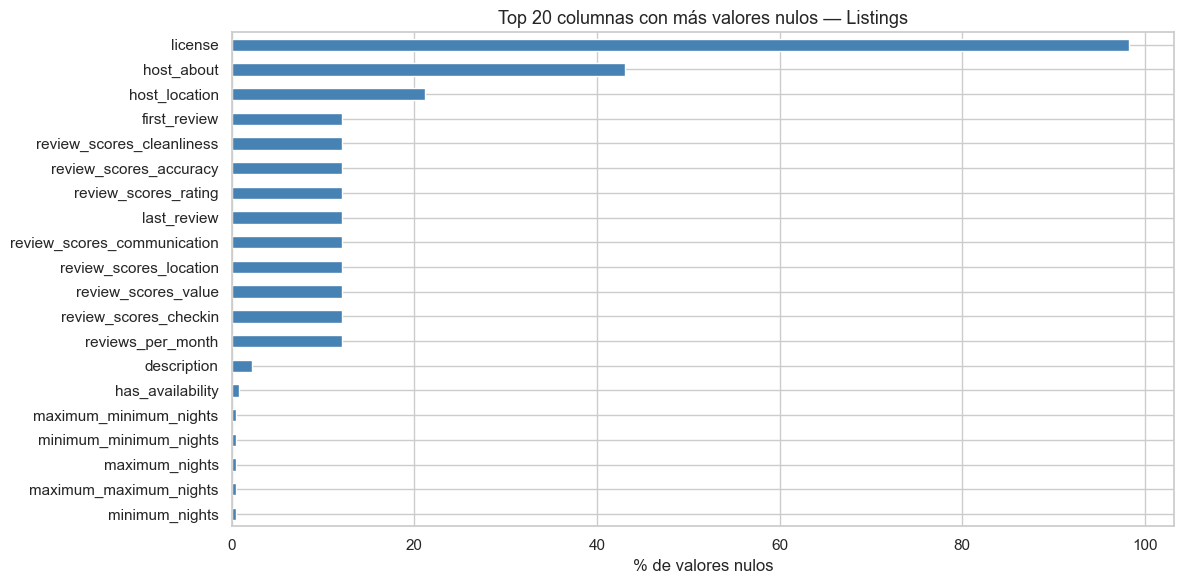

Interpretación: Las columnas con alto % de nulos como license, host_about
y review_scores deberán ser tratadas o excluidas en la fase de transformación.


In [29]:
# Visualización de nulos en Listings (top 20 columnas con más nulos)
if not nulos_listings.empty:
    top20 = nulos_listings.head(20)
    fig, ax = plt.subplots(figsize=(12, 6))
    top20['% Nulos'].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Top 20 columnas con más valores nulos — Listings', fontsize=13)
    ax.set_xlabel('% de valores nulos')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    print('Interpretación: Las columnas con alto % de nulos como license, host_about\n'
          'y review_scores deberán ser tratadas o excluidas en la fase de transformación.')

---
## 6. Calidad de datos — Duplicados

In [30]:
def contar_duplicados(df, nombre):
    """
    Cuenta duplicados excluyendo columnas que contienen listas u objetos no hashables,
    ya que pandas no puede compararlos directamente con duplicated().
    """
    cols_problematicas = [
        col for col in df.columns
        if df[col].apply(lambda x: isinstance(x, (list, dict))).any()
    ]
    if cols_problematicas:
        print(f'  [{nombre}] Columnas excluidas (contienen listas/dicts): {cols_problematicas}')

    cols_comparables = [c for c in df.columns if c not in cols_problematicas]
    dup = df[cols_comparables].duplicated().sum()
    print(f'{nombre}: {dup:,} registros duplicados ({dup/len(df)*100:.2f}%)')

for nombre, df in [('Listings', df_listings), ('Reviews', df_reviews), ('Calendar', df_calendar)]:
    contar_duplicados(df, nombre)

print('\nDecisión: Se eliminarán los duplicados exactos en la fase de transformación,'
      ' ya que no aportan información adicional y pueden sesgar los análisis.')

  [Listings] Columnas excluidas (contienen listas/dicts): ['amenities']
Listings: 0 registros duplicados (0.00%)
Reviews: 0 registros duplicados (0.00%)
Calendar: 0 registros duplicados (0.00%)

Decisión: Se eliminarán los duplicados exactos en la fase de transformación, ya que no aportan información adicional y pueden sesgar los análisis.


---
## 7. Análisis de outliers — minimum_nights, availability_365

**Nota:** Este dataset si continene price pero está nulo en Listings

In [ ]:
# Estadísticas de variables clave con posibles outliers
for col in ['minimum_nights', 'maximum_nights', 'availability_365']:
    if col in df_listings.columns:
        serie = pd.to_numeric(df_listings[col], errors='coerce').dropna()
        print(f'--- {col} ---')
        print(serie.describe())
        print()

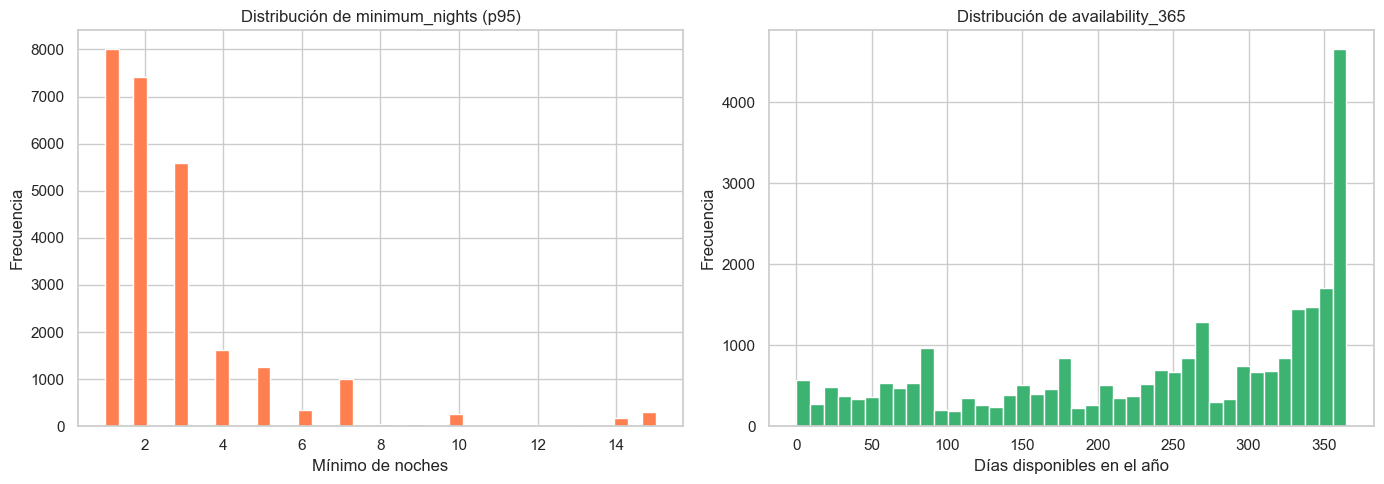

Interpretación: minimum_nights tiene outliers altos (máx 730 días) que sugieren alquileres de larga temporada.
availability_365 muestra cómo varía la oferta activa durante el año.


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de minimum_nights
if 'minimum_nights' in df_listings.columns:
    mn = pd.to_numeric(df_listings['minimum_nights'], errors='coerce').dropna()
    mn_filtrado = mn[mn <= mn.quantile(0.95)]
    axes[0].hist(mn_filtrado, bins=40, color='coral', edgecolor='white')
    axes[0].set_title('Distribución de minimum_nights (p95)', fontsize=12)
    axes[0].set_xlabel('Mínimo de noches')
    axes[0].set_ylabel('Frecuencia')

# Distribución de availability_365
if 'availability_365' in df_listings.columns:
    av = pd.to_numeric(df_listings['availability_365'], errors='coerce').dropna()
    axes[1].hist(av, bins=40, color='mediumseagreen', edgecolor='white')
    axes[1].set_title('Distribución de availability_365', fontsize=12)
    axes[1].set_xlabel('Días disponibles en el año')
    axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print('Interpretación: minimum_nights tiene outliers altos (máx 730 días) que sugieren'
      ' alquileres de larga temporada.\n'
      'availability_365 muestra cómo varía la oferta activa durante el año.')

---
## 8. Distribución por tipo de habitación y barrio

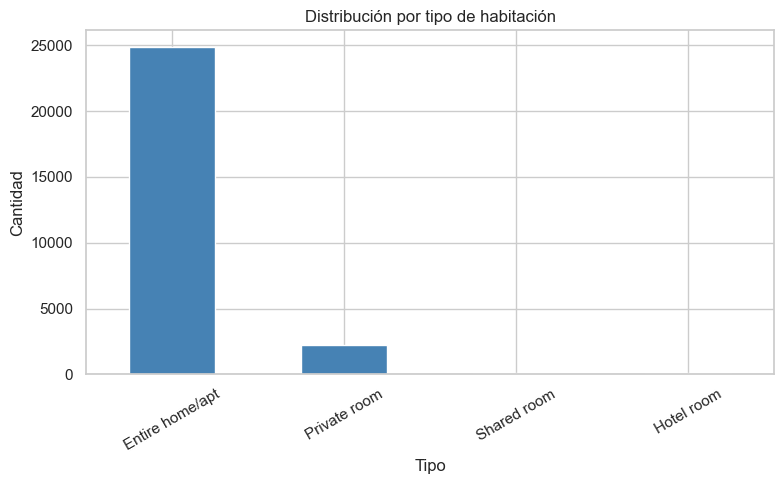

Interpretación: El tipo de alojamiento más frecuente revela el perfil del mercado de Airbnb en Buenos Aires.
room_type
Entire home/apt    24890
Private room        2249
Shared room          132
Hotel room            77
Name: count, dtype: int64


In [48]:
if 'room_type' in df_listings.columns:
    conteo = df_listings['room_type'].value_counts()
    fig, ax = plt.subplots(figsize=(8, 5))
    conteo.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Distribución por tipo de habitación', fontsize=12)
    ax.set_xlabel('Tipo')
    ax.set_ylabel('Cantidad')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()
    print('Interpretación: El tipo de alojamiento más frecuente revela el perfil'
          ' del mercado de Airbnb en Buenos Aires.')
    print(conteo)

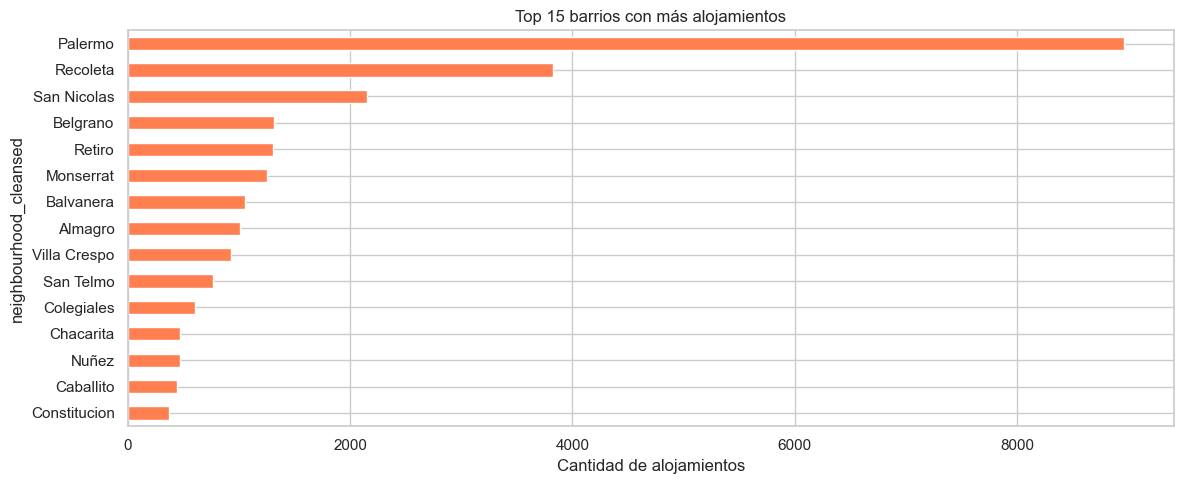

Interpretación: Los barrios con mayor oferta concentran la actividad turística de Buenos Aires.


In [49]:
if 'neighbourhood_cleansed' in df_listings.columns:
    top_barrios = df_listings['neighbourhood_cleansed'].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(12, 5))
    top_barrios.plot(kind='barh', ax=ax, color='coral')
    ax.set_title('Top 15 barrios con más alojamientos', fontsize=12)
    ax.set_xlabel('Cantidad de alojamientos')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    print('Interpretación: Los barrios con mayor oferta concentran la actividad'
          ' turística de Buenos Aires.')

---
## 9. Análisis del host — Superhosts y antigüedad

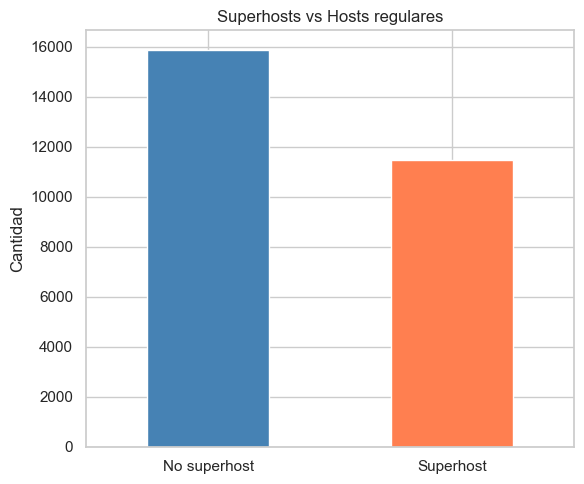

Porcentaje de Superhosts: 42.0%
Interpretación: Una alta proporción de Superhosts indica un mercado con anfitriones experimentados y bien valorados.


In [50]:
# Proporción de superhosts
if 'host_is_superhost' in df_listings.columns:
    conteo_super = df_listings['host_is_superhost'].value_counts()
    fig, ax = plt.subplots(figsize=(6, 5))
    conteo_super.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='white')
    ax.set_title('Superhosts vs Hosts regulares', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Cantidad')
    ax.set_xticklabels(['No superhost', 'Superhost'] if conteo_super.index[0] == False
                       else ['Superhost', 'No superhost'], rotation=0)
    plt.tight_layout()
    plt.show()
    pct = (conteo_super.get(True, 0) / len(df_listings) * 100)
    print(f'Porcentaje de Superhosts: {pct:.1f}%')
    print('Interpretación: Una alta proporción de Superhosts indica un mercado'
          ' con anfitriones experimentados y bien valorados.')

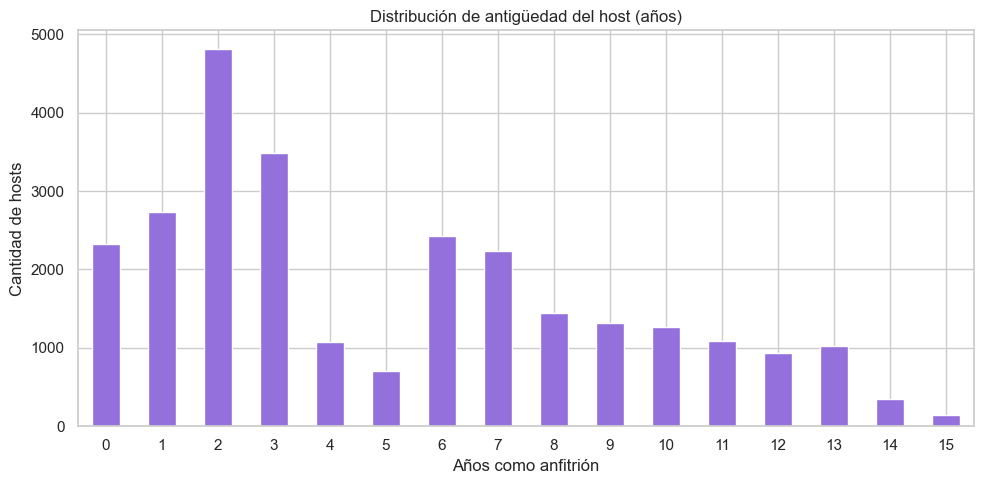

Media: 5.1 años | Máximo: 15 años
Interpretación: La distribución de antigüedad refleja la madurez del mercado Airbnb en Buenos Aires.


In [51]:
# Antigüedad del host como anfitrión
if 'hosts_time_as_host_years' in df_listings.columns:
    años_host = pd.to_numeric(df_listings['hosts_time_as_host_years'], errors='coerce').dropna()
    fig, ax = plt.subplots(figsize=(10, 5))
    años_host.value_counts().sort_index().plot(kind='bar', ax=ax,
                                               color='mediumpurple', edgecolor='white')
    ax.set_title('Distribución de antigüedad del host (años)', fontsize=12)
    ax.set_xlabel('Años como anfitrión')
    ax.set_ylabel('Cantidad de hosts')
    ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()
    print(f'Media: {años_host.mean():.1f} años | Máximo: {años_host.max():.0f} años')
    print('Interpretación: La distribución de antigüedad refleja la madurez del'
          ' mercado Airbnb en Buenos Aires.')

---
## 10. Análisis de Reviews — Distribución temporal

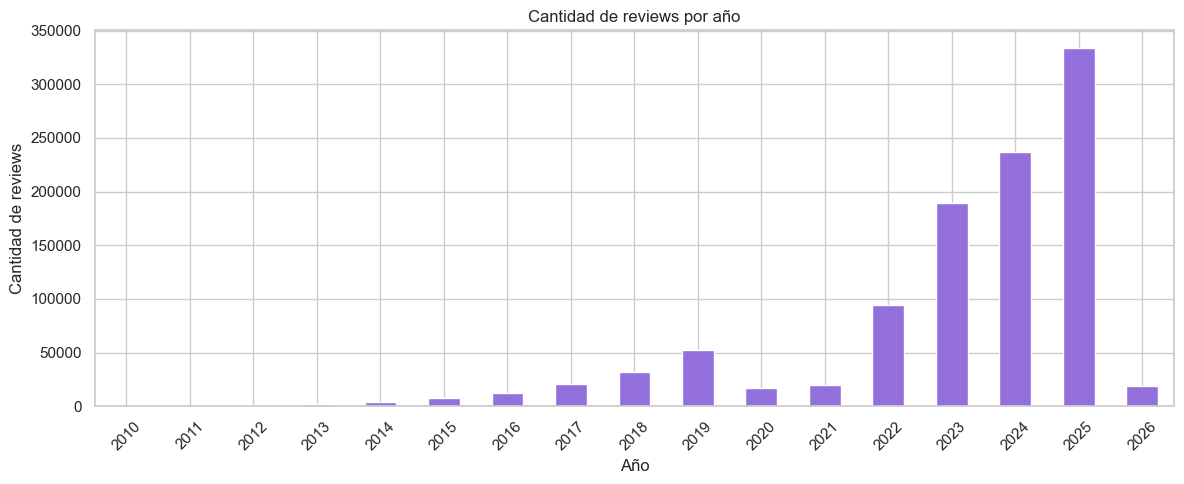

Interpretación: El volumen de reviews muestra la evolución de la actividad de Airbnb en Buenos Aires a lo largo del tiempo.


In [52]:
if 'date' in df_reviews.columns:
    # La columna date ya viene como datetime desde MongoDB
    df_reviews_temp = df_reviews.copy()
    df_reviews_temp['date_dt'] = pd.to_datetime(df_reviews_temp['date'], errors='coerce')
    df_reviews_temp['anio'] = df_reviews_temp['date_dt'].dt.year
    conteo_anio = df_reviews_temp['anio'].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(12, 5))
    conteo_anio.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
    ax.set_title('Cantidad de reviews por año', fontsize=12)
    ax.set_xlabel('Año')
    ax.set_ylabel('Cantidad de reviews')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    print('Interpretación: El volumen de reviews muestra la evolución de la'
          ' actividad de Airbnb en Buenos Aires a lo largo del tiempo.')

---
## 11. Análisis de Calendar — Disponibilidad por mes

El análisis se centra en la **disponibilidad** de los alojamientos a lo largo del año.

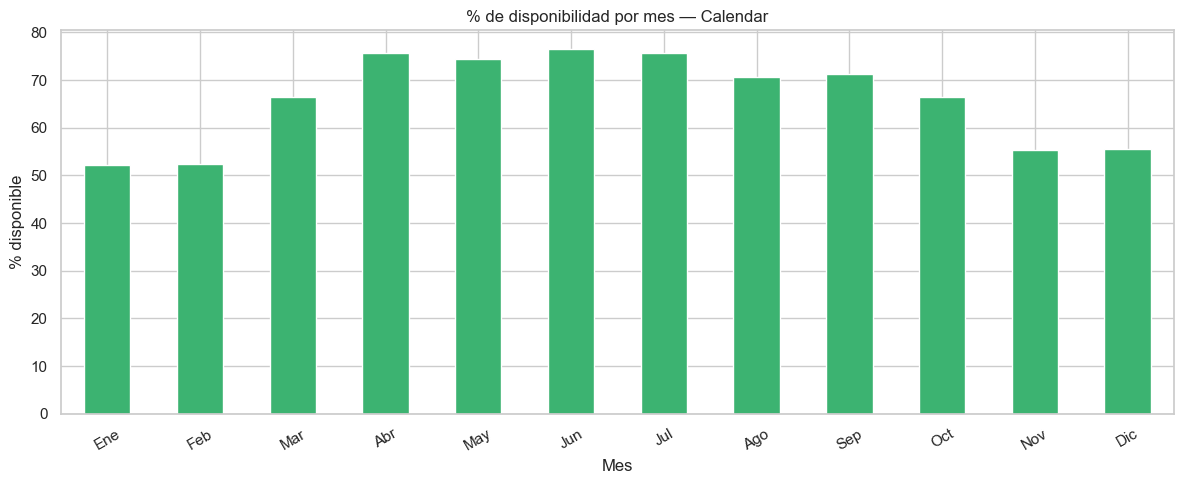

Interpretación: Los meses con menor disponibilidad corresponden a temporadas de mayor demanda turística en Buenos Aires.


In [53]:
# Disponibilidad por mes
if 'available' in df_calendar.columns and 'date' in df_calendar.columns:
    df_cal = df_calendar.copy()
    df_cal['date_dt'] = pd.to_datetime(df_cal['date'], errors='coerce')
    df_cal['mes'] = df_cal['date_dt'].dt.month

    # available ya viene como bool desde MongoDB
    df_cal['disponible'] = df_cal['available'].astype(bool).astype(int)

    disp_mes = df_cal.groupby('mes')['disponible'].mean() * 100

    fig, ax = plt.subplots(figsize=(12, 5))
    disp_mes.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
    ax.set_title('% de disponibilidad por mes — Calendar', fontsize=12)
    ax.set_xlabel('Mes')
    ax.set_ylabel('% disponible')
    ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                        'Jul','Ago','Sep','Oct','Nov','Dic'], rotation=30)
    plt.tight_layout()
    plt.show()
    print('Interpretación: Los meses con menor disponibilidad corresponden a'
          ' temporadas de mayor demanda turística en Buenos Aires.')

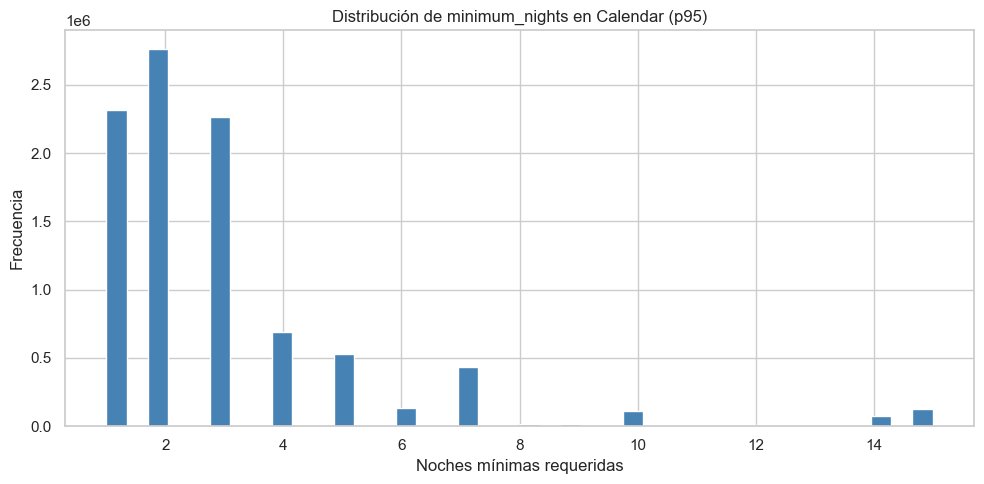

Mediana: 2 | Máximo: 730
Interpretación: La mayoría de los alojamientos requiere pocas noches mínimas, aunque hay casos con restricciones muy altas.


In [54]:
# Distribución de minimum_nights en Calendar
if 'minimum_nights' in df_calendar.columns:
    mn_cal = pd.to_numeric(df_calendar['minimum_nights'], errors='coerce').dropna()
    mn_cal_filtrado = mn_cal[mn_cal <= mn_cal.quantile(0.95)]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(mn_cal_filtrado, bins=40, color='steelblue', edgecolor='white')
    ax.set_title('Distribución de minimum_nights en Calendar (p95)', fontsize=12)
    ax.set_xlabel('Noches mínimas requeridas')
    ax.set_ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()
    print(f'Mediana: {mn_cal.median():.0f} | Máximo: {mn_cal.max():.0f}')
    print('Interpretación: La mayoría de los alojamientos requiere pocas noches'
          ' mínimas, aunque hay casos con restricciones muy altas.')

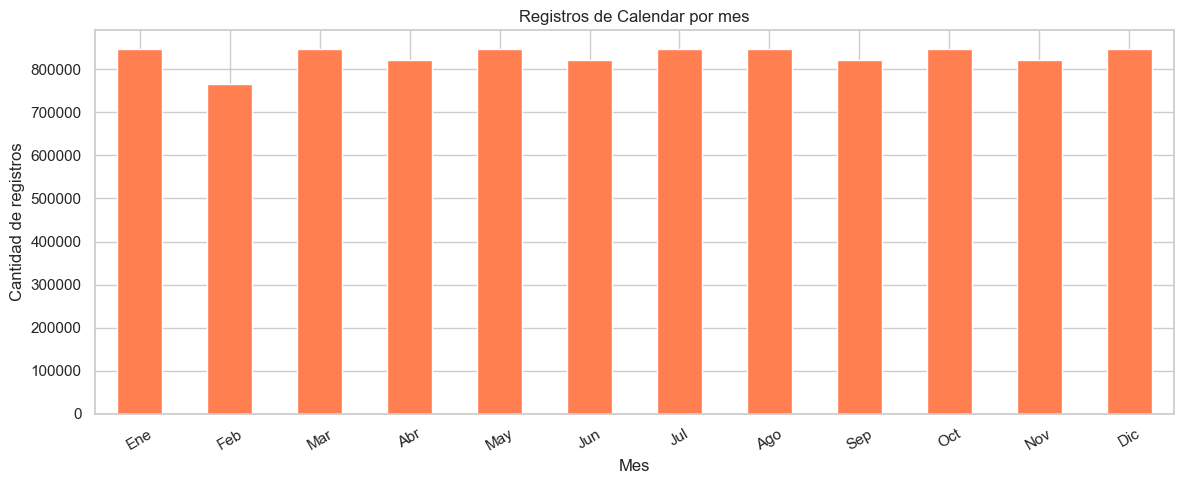

Interpretación: La distribución de registros por mes refleja el horizonte de planificación del scraping de Airbnb.


In [55]:
# Distribución temporal del calendar: registros por mes
if 'date' in df_calendar.columns:
    df_cal2 = df_calendar.copy()
    df_cal2['date_dt'] = pd.to_datetime(df_cal2['date'], errors='coerce')
    df_cal2['mes'] = df_cal2['date_dt'].dt.month
    conteo_mes = df_cal2['mes'].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(12, 5))
    conteo_mes.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
    ax.set_title('Registros de Calendar por mes', fontsize=12)
    ax.set_xlabel('Mes')
    ax.set_ylabel('Cantidad de registros')
    ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                        'Jul','Ago','Sep','Oct','Nov','Dic'], rotation=30)
    plt.tight_layout()
    plt.show()
    print('Interpretación: La distribución de registros por mes refleja el'
          ' horizonte de planificación del scraping de Airbnb.')

---
## 12. Análisis del campo amenities en Listings

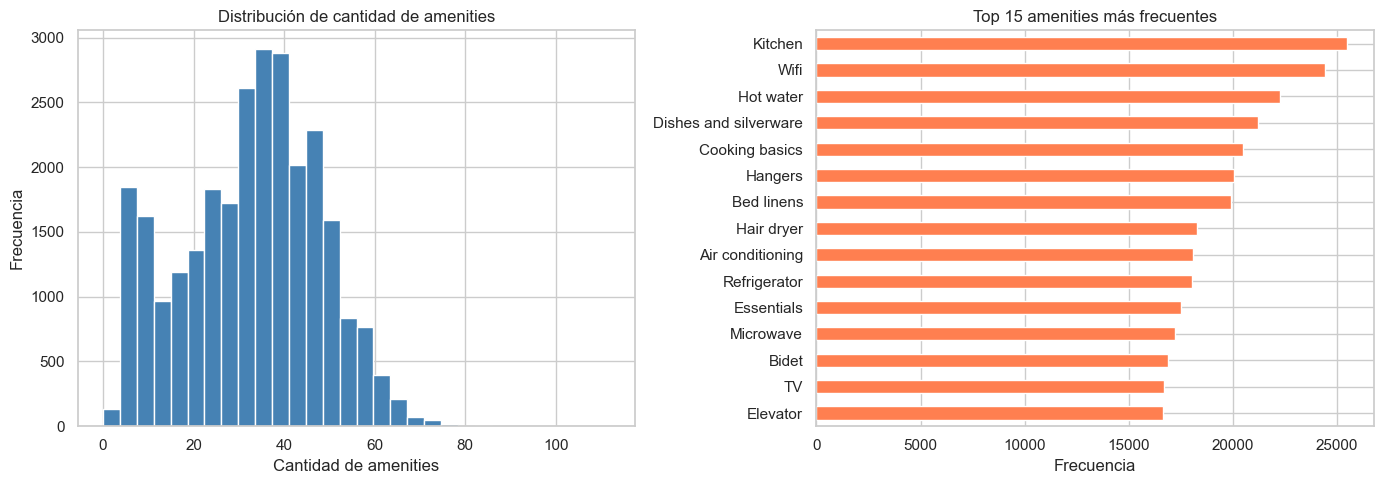

Media de amenities por listing: 32.6
Interpretación: El campo amenities viene como lista desde MongoDB.
En la transformación se extraerá la cantidad como variable numérica.


In [56]:
# amenities viene como lista Python (deserializado desde MongoDB)
if 'amenities' in df_listings.columns:
    def contar_amenities(val):
        if isinstance(val, list):
            return len(val)
        return 0

    cantidad_amenities = df_listings['amenities'].apply(contar_amenities)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma
    axes[0].hist(cantidad_amenities, bins=30, color='steelblue', edgecolor='white')
    axes[0].set_title('Distribución de cantidad de amenities', fontsize=12)
    axes[0].set_xlabel('Cantidad de amenities')
    axes[0].set_ylabel('Frecuencia')

    # Top amenities más frecuentes
    from collections import Counter
    todas = [a for sublist in df_listings['amenities'] if isinstance(sublist, list)
             for a in sublist]
    top_amenities = pd.Series(Counter(todas)).sort_values(ascending=False).head(15)
    top_amenities.plot(kind='barh', ax=axes[1], color='coral')
    axes[1].set_title('Top 15 amenities más frecuentes', fontsize=12)
    axes[1].set_xlabel('Frecuencia')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()
    print(f'Media de amenities por listing: {cantidad_amenities.mean():.1f}')
    print('Interpretación: El campo amenities viene como lista desde MongoDB.\n'
          'En la transformación se extraerá la cantidad como variable numérica.')

---
## 13. Análisis de review scores

In [57]:
cols_scores = ['review_scores_rating', 'review_scores_accuracy',
               'review_scores_cleanliness', 'review_scores_checkin',
               'review_scores_communication', 'review_scores_location',
               'review_scores_value']
cols_scores_ok = [c for c in cols_scores if c in df_listings.columns]

if cols_scores_ok:
    # Solo registros con al menos un score
    df_scores = df_listings[cols_scores_ok].dropna(how='all')
    print(f'Listings con al menos un review score: {len(df_scores):,}')
    print(f'Listings SIN review scores: {len(df_listings) - len(df_scores):,}'
          f' ({(len(df_listings) - len(df_scores))/len(df_listings)*100:.1f}%)')
    print()
    print(df_scores.describe())

Listings con al menos un review score: 24,045
Listings SIN review scores: 3,303 (12.1%)

       review_scores_rating  review_scores_accuracy  \
count              24045.00                24044.00   
mean                   4.78                    4.81   
std                    0.36                    0.34   
min                    1.00                    1.00   
25%                    4.73                    4.77   
50%                    4.87                    4.89   
75%                    4.98                    4.99   
max                    5.00                    5.00   

       review_scores_cleanliness  review_scores_checkin  \
count                   24045.00               24045.00   
mean                        4.74                   4.87   
std                         0.38                   0.29   
min                         1.00                   1.00   
25%                         4.67                   4.85   
50%                         4.83                   4.95   
75

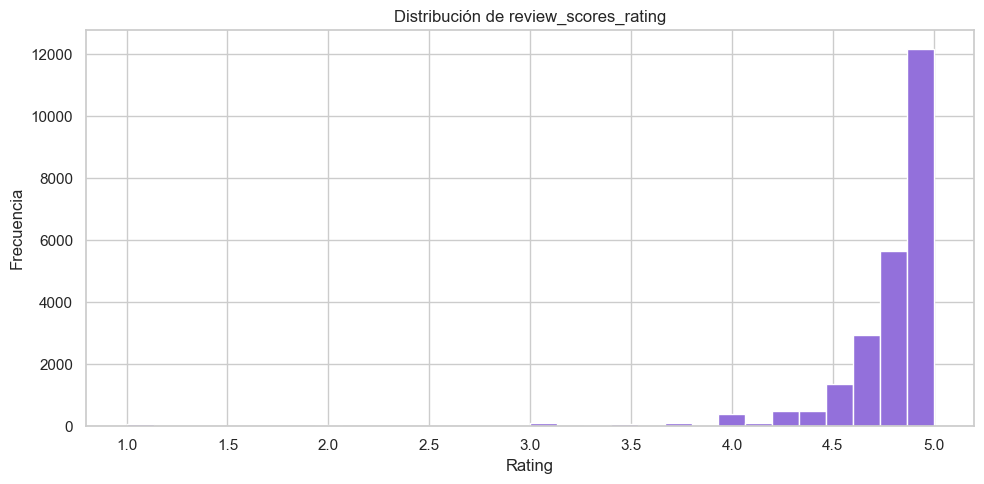

Media: 4.78 | Mediana: 4.87
Interpretación: La mayoría de los alojamientos tiene ratings altos, lo cual es típico en plataformas de economía colaborativa.


In [58]:
if cols_scores_ok and 'review_scores_rating' in df_listings.columns:
    rating = df_listings['review_scores_rating'].dropna()
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(rating, bins=30, color='mediumpurple', edgecolor='white')
    ax.set_title('Distribución de review_scores_rating', fontsize=12)
    ax.set_xlabel('Rating')
    ax.set_ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()
    print(f'Media: {rating.mean():.2f} | Mediana: {rating.median():.2f}')
    print('Interpretación: La mayoría de los alojamientos tiene ratings altos,'
          ' lo cual es típico en plataformas de economía colaborativa.')

---
## 14. Posibles transformaciones identificadas

A partir del análisis exploratorio se identificaron los siguientes requerimientos de transformación:

| Colección | Campo | Problema detectado | Acción en transformacion.py |
|---|---|---|---|
| Listings | amenities | Lista de Python (deserializada desde MongoDB) | Extraer cantidad como variable numérica |
| Listings | last_scraped, calendar_last_scraped | Tipo datetime64 | Convertir a string YYYY-MM-DD |
| Listings | minimum_nights | Outliers extremos (máx 730) | Registrar en log, conservar para análisis posterior |
| Listings | license | 98.3% de valores nulos | Excluir o marcar como 'Sin licencia' |
| Listings | review_scores_* | 12% de valores nulos | Rellenar con 0 (sin reseñas) |
| Calendar | available | Tipo bool nativo | Ya correcto, no requiere conversión |
| Calendar | date | Tipo datetime64 | Convertir a string YYYY-MM-DD y derivar mes, año, trimestre |
| Reviews | comments | 1 valor nulo | Rellenar con 'Sin comentario' |
| Todos | Duplicados exactos | 0 duplicados detectados | No se requiere acción (confirmar en transformación) |

---
## 15. Resumen de hallazgos del EDA

**Listings (27.348 registros, 71 columnas):**
- **`price`** en listings esta completamente null.
- `license` tiene un 98.3% de valores nulos — prácticamente inutilizable.
- Los campos de review scores tienen un 12% de nulos, correspondientes a alojamientos sin reseñas.
- `amenities` llega como lista de Python desde MongoDB — se deberá extraer su cantidad.
- `minimum_nights` tiene outliers altos (hasta 730 noches) que indican alquileres de larga temporada.
- Los campos de fecha (`last_scraped`, `calendar_last_scraped`) ya vienen deserializados correctamente como `datetime64`.

**Reviews (1.042.702 registros, 6 columnas):**
- Dataset limpio: solo 1 valor nulo en `reviewer_name`, 0 duplicados.
- La columna `date` ya es `datetime64` — no requiere conversión.
- La distribución temporal muestra la evolución histórica de la plataforma.

**Calendar (9.982.072 registros, 5 columnas):**
- Dataset completamente limpio: 0 nulos, 0 duplicados.
- `available` ya es tipo `bool` nativo desde MongoDB.
- `date` ya es `datetime64` — solo se derivarán las variables de tiempo.
- **No tiene campo `price`** — el precio en este dataset no fue capturado en el scraping.